<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/santi/Ejercicio3_ACV_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 3 — Predicción de Riesgo de ACV con Redes Neuronales
## Inteligencia Computacional — IC415 | RA1 Laboratorio N° 1

**Grupo 8:** Alex Nahuel Acosta · Santiago Daniel Bareiro · Agustín Marcelo Borges

**Fecha:** 05/2026

---

> **Nota de lectura.** Este notebook es la continuación directa del Laboratorio N° 1 de ML Clásico.
> No se repite el EDA ni la justificación de las decisiones de preprocesamiento: se retoman como
> punto de partida y se analizan sus implicancias específicas para una Red Neuronal Artificial (RNA).
> El foco está en el contraste técnico entre ambos enfoques sobre el mismo problema clínico.

---


---
## 1. Configuración del entorno y semillas <a id='1-setup'></a>

Fijar semillas en TensorFlow, NumPy y Python es una condición necesaria —pero no siempre suficiente—
para la reproducibilidad. Keras/TensorFlow tiene fuentes adicionales de aleatoriedad (operaciones
de GPU, paralelismo de capas) que pueden introducir variaciones mínimas entre corridas incluso
con semillas fijas. En CPU pura, la reproducibilidad es prácticamente garantizada.


In [1]:
import os, sys, warnings, time
warnings.filterwarnings("ignore")

# ── Semillas globales — DEBEN fijarse ANTES de importar TensorFlow ────────────
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)

import numpy as np
np.random.seed(SEED)

import random
random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)
# Determinismo en GPU (puede reducir performance, pero garantiza reproducibilidad)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    recall_score, precision_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, precision_recall_curve,
    matthews_corrcoef
)

from imblearn.over_sampling import SMOTE

from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

print(f"TensorFlow  : {tf.__version__}")
print(f"Keras       : {keras.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"Python      : {sys.version.split()[0]}")
print(f"Semilla fija: SEED = {SEED}")


TensorFlow  : 2.20.0
Keras       : 3.13.2
NumPy       : 2.0.2
Python      : 3.12.13
Semilla fija: SEED = 42


---
## 2. Carga del dataset y preprocesamiento <a id='2-prep'></a>

Se replica exactamente el pipeline del Laboratorio N° 1, con un cambio importante
que se justifica en la sección siguiente: se utiliza **StandardScaler** (ya estaba en el lab)
en lugar de MinMaxScaler, y se argumenta por qué esa elección es incluso más crítica para una RNA.

El orden del pipeline es el mismo que en el lab anterior:
`SPLIT → ENCODE → IMPUTE (fit en train) → SCALE (fit en train) → SMOTE (solo en train)`


In [2]:
# ── Carga del dataset ────────────────────────────────────────────────────────
URL = "https://raw.githubusercontent.com/Santibareiro27/Inteligencia-Computacional/main/RA1_LAB1/datos_acv.csv"
df = pd.read_csv(URL)

print(f"Dimensiones originales: {df.shape}")
print(f"Prevalencia de ACV: {df['apoplejia'].mean()*100:.2f}%")


Dimensiones originales: (5110, 12)
Prevalencia de ACV: 4.87%


In [3]:
# Visualización de las primeras filas del dataset procesado
display(df.head())

print(f"\nDimensiones actuales: {df.shape}")
print(f"Columnas disponibles: {df.columns.tolist()}")

,id,genero,edad,hipertension,enfermedad_corazon,casado_alguna_vez,tipo_trabajo,tipo_residencia,nivel_glucosa,imc,estado_fumador,apoplejia
0,9046,hombre,67.0,0,1,1,privado,urbano,228.69,36.6,fumaba,1
1,51676,mujer,61.0,0,0,1,autonomo,rural,202.21,NaN,nunca,1
2,31112,hombre,80.0,0,1,1,privado,rural,105.92,32.5,nunca,1
3,60182,mujer,49.0,0,0,1,privado,urbano,171.23,34.4,fuma,1
4,1665,mujer,79.0,1,0,1,autonomo,rural,174.12,24.0,nunca,1



Dimensiones actuales: (5110, 12)
Columnas disponibles: ['id', 'genero', 'edad', 'hipertension', 'enfermedad_corazon', 'casado_alguna_vez', 'tipo_trabajo', 'tipo_residencia', 'nivel_glucosa', 'imc', 'estado_fumador', 'apoplejia']


In [4]:
# ── Limpieza — mismas decisiones del Lab 1 ───────────────────────────────────
# Eliminación de categorías con un solo individuo o sin representación en ACV
df = df[df['genero'] != 'otro'].copy()
df = df[df['tipo_trabajo'] != 'nunca_trabajo'].copy()

# Outliers → NaN (serán imputados con KNN)
df.loc[(df['imc'] < 12) | (df['imc'] > 60), 'imc'] = np.nan
df.loc[df['nivel_glucosa'] < 40, 'nivel_glucosa'] = np.nan

# Eliminación de features de baja relevancia (justificadas en Lab 1)
COLS_DROP = ['id', 'casado_alguna_vez', 'tipo_trabajo', 'tipo_residencia']
df.drop(columns=[c for c in COLS_DROP if c in df.columns], inplace=True)

# Target a entero
df['apoplejia'] = df['apoplejia'].astype(int)

print(f"Dimensiones post-limpieza: {df.shape}")
print(f"Features finales: {df.drop('apoplejia', axis=1).columns.tolist()}")


Dimensiones post-limpieza: (5087, 8)
Features finales: ['genero', 'edad', 'hipertension', 'enfermedad_corazon', 'nivel_glucosa', 'imc', 'estado_fumador']


In [5]:
# ── Split estratificado — PRIMER PASO (antes de cualquier fit) ───────────────
X = df.drop('apoplejia', axis=1)
y = df['apoplejia']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,         # preserva proporción ACV/no-ACV en ambos splits
    random_state=SEED
)

print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print(f"ACV en train: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"ACV en test : {y_test.sum()}  ({y_test.mean()*100:.2f}%)")


Train: 4,069  |  Test: 1,018
ACV en train: 199 (4.89%)
ACV en test : 50  (4.91%)


In [6]:
# ── Encoding de categóricas ───────────────────────────────────────────────────

# Reemplazar 'desconocido' por NaN (no aporta información clínica)
if 'estado_fumador' in X_train.columns:
    X_train['estado_fumador'] = X_train['estado_fumador'].replace('desconocido', np.nan)
    X_test['estado_fumador']  = X_test['estado_fumador'].replace('desconocido', np.nan)

# Encoding ordinal/binario
SMOKING_MAP = {'nunca': 0, 'fumaba': 1, 'fuma': 2}
GENDER_MAP  = {'hombre': 0, 'mujer': 1}

for df_part in [X_train, X_test]:
    if 'estado_fumador' in df_part.columns:
        df_part['estado_fumador'] = df_part['estado_fumador'].map(SMOKING_MAP)
    if 'genero' in df_part.columns:
        df_part['genero'] = df_part['genero'].map(GENDER_MAP)

print("Encoding aplicado.")
print("Shape:", X_train.shape)
print("Columnas:", X_train.columns.tolist())
print("\nNaN por columna:")
print(X_train.isnull().sum())
print("\nDtypes:")
print(X_train.dtypes)


Encoding aplicado.
Shape: (4069, 7)
Columnas: ['genero', 'edad', 'hipertension', 'enfermedad_corazon', 'nivel_glucosa', 'imc', 'estado_fumador']

NaN por columna:
genero                   0
edad                     0
hipertension             0
enfermedad_corazon       0
nivel_glucosa            0
imc                    176
estado_fumador        1234
dtype: int64

Dtypes:
genero                  int64
edad                  float64
hipertension            int64
enfermedad_corazon      int64
nivel_glucosa         float64
imc                   float64
estado_fumador        float64
dtype: object


In [7]:
# ── Imputación KNN — fit EXCLUSIVAMENTE en train ─────────────────────────────
# Paso 1: escalado temporal para que KNN use distancias euclidianas equitativas
scaler_knn = StandardScaler()
X_train_sc_tmp = scaler_knn.fit_transform(X_train)
X_test_sc_tmp  = scaler_knn.transform(X_test)

# Paso 2: KNN imputer (k=5 vecinos)
imputer = KNNImputer(n_neighbors=5)
X_train_imp = imputer.fit_transform(X_train_sc_tmp)
X_test_imp  = imputer.transform(X_test_sc_tmp)

# Volver a DataFrame con nombres de columnas
X_train = pd.DataFrame(X_train_imp, columns=X_train.columns)
X_test  = pd.DataFrame(X_test_imp,  columns=X_test.columns)

print(f"Faltantes post-imputación: {X_train.isnull().sum().sum()}")


Faltantes post-imputación: 0


In [8]:
# ── Escalado definitivo StandardScaler — fit SOLO en train ───────────────────
# Justificación extendida en la sección 3.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convertir a arrays numpy (requerido por Keras)
X_train_scaled = X_train_scaled.astype(np.float32)
X_test_scaled  = X_test_scaled.astype(np.float32)
y_train_arr    = y_train.values.astype(np.float32)
y_test_arr     = y_test.values.astype(np.float32)

print(f"Shape X_train_scaled: {X_train_scaled.shape}")
print(f"Shape X_test_scaled : {X_test_scaled.shape}")
print(f"Media  (debe ser ~0): {X_train_scaled.mean(axis=0)[:4].round(3)}")
print(f"Desvío (debe ser ~1): {X_train_scaled.std(axis=0)[:4].round(3)}")


Shape X_train_scaled: (4069, 7)
Shape X_test_scaled : (1018, 7)
Media  (debe ser ~0): [ 0.  0. -0. -0.]
Desvío (debe ser ~1): [1. 1. 1. 1.]


---
## 3. Pregunta 1: Implicancias del preprocesamiento en la RNA <a id='3-preproc-rna'></a>

> *¿Qué cambia en el preprocesamiento cuando pasamos de un árbol de decisión a una red neuronal?*

### 3.1 Escalado: crítico para RNA, irrelevante para árboles

Un árbol de decisión (Random Forest, XGBoost) **no necesita escalado**: sus splits son umbrales
sobre una sola variable a la vez, independientes de la magnitud. Una neurona, en cambio,
calcula una suma ponderada: `z = w₁·x₁ + w₂·x₂ + ... + b`. Si `x₁` está en [0, 100]
y `x₂` en [0, 1], los gradientes del descenso estocástico serán órdenes de magnitud
distintos para cada peso, haciendo el entrenamiento inestable o muy lento.

**StandardScaler** (media=0, std=1) es la elección correcta para redes neuronales con
activaciones ReLU: los valores centrados en cero favorecen los gradientes en la primera época
y reducen el tiempo de convergencia. MinMaxScaler [0,1] funciona pero concentra la información
en un rango positivo, lo que puede limitar la expresividad de ReLU.

### 3.2 Encoding ordinal vs one-hot

El encoding ordinal de `estado_fumador` (nunca=0, fumaba=1, fuma=2) introduce un orden
que para una RNA tiene implicancias distintas que para un árbol:
- En un árbol, el split puede ocurrir en cualquier umbral, por lo que el orden relativo
  importa poco si hay splits por izquierda y derecha.
- En una RNA, el valor numérico entra directamente como feature, y la red puede interpretar
  que `fuma=2` es "dos veces" `fumaba=1`, lo cual no es fisiológicamente preciso.
  
**¿Cambiaríamos algo?** Para una RNA con suficientes datos, **one-hot encoding** sería preferible
para variables categóricas sin orden claro. Sin embargo, con ~5100 registros y solo 3 categorías,
el encoding ordinal es una aproximación razonable que evita aumentar la dimensionalidad.

### 3.3 Imputación KNN — sin cambios necesarios

La imputación KNN es agnóstica al modelo downstream: genera valores plausibles basados en
vecindad euclidiana. Para una RNA esto es apropiado porque los valores imputados mantienen
la distribución del resto de las variables, lo cual el escalado posterior consolida.

### 3.4 SMOTE — exclusivamente en train

SMOTE genera muestras sintéticas de la clase minoritaria **interpolando** entre vecinos en el
espacio de features. Aplicarlo antes del split contaminaría el test con información del train
(data leakage). La RNA entrenará sobre el train balanceado artificialmente y será evaluada
sobre el test original con la distribución real de la población.

| Decisión de preprocesamiento | Árbol | RNA | ¿Cambia algo? |
|---|---|---|---|
| Escalado | No necesario | **Crítico** | Sí — StandardScaler obligatorio |
| Encoding ordinal | Robusto | Puede introducir sesgos | Preferible one-hot con más datos |
| Imputación KNN | Válido | Válido | No cambia |
| SMOTE solo en train | Correcto | Correcto | No cambia |


---
## 4. Desbalance de clases: estrategia y fundamentación <a id='4-desbalance'></a>

> *El dataset tiene ~5% de casos positivos (ACV). ¿Es necesario tomar precauciones?*

**Sí, es absolutamente necesario.** Un modelo que predice siempre "sin ACV" obtiene ~95% de
accuracy pero 0% de Recall: ignora completamente los casos clínicamente relevantes.

### Estrategias evaluadas

| Estrategia | Descripción | Ventaja | Limitación |
|---|---|---|---|
| **class_weight** | Penaliza más los errores en la clase minoritaria durante el entrenamiento | Sin nuevos datos, simple | Solo repondera la pérdida |
| **SMOTE** | Genera muestras sintéticas interpoladas | Más ejemplos reales de la minoría | Puede generar puntos no representativos |
| **Combinada** | SMOTE + class_weight | Máxima presión sobre la minoría | Mayor riesgo de overfitting |

### Estrategia seleccionada: class_weight en Keras

Para este problema clínico con ~5100 registros, se elige **class_weight** como estrategia
principal por las siguientes razones:

1. **Datos limitados**: SMOTE con ~250 positivos puede generar muestras sintéticas poco
   representativas de la distribución real de pacientes con ACV.
2. **Simplicidad y controlabilidad**: class_weight es un hiperparámetro de Keras directamente
   calibrable sin alterar los datos de entrada.
3. **Conservación de la distribución original**: el modelo ve los datos reales, no interpolaciones.


In [9]:
# ── Cálculo de class_weight ───────────────────────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

clases = np.unique(y_train_arr)
pesos = compute_class_weight(class_weight='balanced', classes=clases, y=y_train_arr)
class_weight_dict = {int(c): float(w) for c, w in zip(clases, pesos)}

print("Class weights calculados automáticamente:")
for cls, w in class_weight_dict.items():
    n = (y_train_arr == cls).sum()
    label = "Sin ACV" if cls == 0 else "Con ACV"
    print(f"  Clase {cls} ({label}): peso = {w:.3f}  (n={int(n):,})")

print()
print("Interpretación: el modelo penaliza los errores en pacientes con ACV")
print(f"{class_weight_dict[1]/class_weight_dict[0]:.1f}x más que los errores en pacientes sin ACV.")


Class weights calculados automáticamente:
  Clase 0 (Sin ACV): peso = 0.526  (n=3,870)
  Clase 1 (Con ACV): peso = 10.224  (n=199)

Interpretación: el modelo penaliza los errores en pacientes con ACV
19.4x más que los errores en pacientes sin ACV.


In [10]:
# ── SMOTE — preparado para uso combinado (evaluación posterior) ──────────────
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train_arr)

print(f"Train original : {X_train_scaled.shape[0]:,} ({y_train_arr.mean()*100:.1f}% ACV)")
print(f"Train con SMOTE: {X_train_sm.shape[0]:,} ({y_train_sm.mean()*100:.1f}% ACV)")


Train original : 4,069 (4.9% ACV)
Train con SMOTE: 7,740 (50.0% ACV)


---
## 5. Exploración de arquitecturas <a id='5-arquitecturas'></a>

> *¿A partir de qué tamaño logra la red desempeñar la tarea con cierta eficiencia?
> ¿Qué ocurre con arquitecturas muy pequeñas o muy grandes dado el tamaño del dataset?*

Se exploran cuatro arquitecturas con creciente complejidad, evaluando el trade-off entre
capacidad de representación y riesgo de overfitting dado el tamaño limitado del dataset (~4100 train).

| Arquitectura | Capas ocultas | Neuronas | Parámetros approx. | Diagnóstico esperado |
|---|---|---|---|---|
| **Tiny** | 1 | 8 | ~100 | Underfitting: capacidad insuficiente |
| **Small** | 1 | 32 | ~400 | Baseline razonable |
| **Medium** | 2 | 64-32 | ~2.600 | Balance capacidad/generalización |
| **Large** | 4 | 128-64-32-16 | ~14.000 | Riesgo de overfitting con ~5100 datos |


In [11]:
N_FEATURES = X_train_scaled.shape[1]

def build_model(architecture, seed=SEED):
    """
    Construye un modelo según la arquitectura especificada.
    Todas las capas usan:
    - ReLU: función de activación estándar para capas ocultas. No satura para
      valores positivos, acelera el entrenamiento respecto a sigmoid/tanh.
    - kernel_initializer='he_normal': inicialización recomendada para ReLU.
      Escala los pesos iniciales según el número de neuronas de entrada,
      evitando gradientes que exploten o se anulen desde el inicio.
    - Capa de salida: 1 neurona con sigmoid para clasificación binaria.
    """
    tf.random.set_seed(seed)
    model = keras.Sequential(name=architecture)
    model.add(layers.Input(shape=(N_FEATURES,), name="input"))

    configs = {
        "tiny":   [(8,)],
        "small":  [(16,), (8,)],
        "medium": [(64,), (32,)],
        "large":  [(128,), (64,), (32,), (16,)],
    }

    for i, (units,) in enumerate(configs[architecture]):
        model.add(layers.Dense(
            units,
            activation='relu',
            kernel_initializer='he_normal',
            name=f"hidden_{i+1}_{units}"
        ))

    model.add(layers.Dense(1, activation='sigmoid', name="output"))
    return model

# Compilación y resumen de cada arquitectura
for arch in ["tiny", "small", "medium", "large"]:
    m = build_model(arch)
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['recall'])
    params = m.count_params()
    print(f"{arch.upper():<8}: {params:>6,} parámetros")


TINY    :     73 parámetros
SMALL   :    273 parámetros
MEDIUM  :  2,625 parámetros
LARGE   : 11,905 parámetros


In [12]:
# ── Entrenamiento comparativo de arquitecturas ────────────────────────────────
# EarlyStopping evita que el número de épocas sea un hiperparámetro manual.
# patience=10: tolera 10 épocas sin mejora en val_loss antes de detener.
# restore_best_weights=True: al finalizar, los pesos son los del mejor momento.

early_stop_arch = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=0
)

arch_results = {}

for arch in ["tiny", "small", "medium", "large"]:
    tf.random.set_seed(SEED)
    model = build_model(arch)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['recall']
    )
    t0 = time.time()
    history = model.fit(
        X_train_scaled, y_train_arr,
        epochs=100,
        batch_size=32,       # 32: estándar. Más pequeño → más ruido en gradientes (útil para escapar mínimos locales)
        validation_split=0.15,
        class_weight=class_weight_dict,
        callbacks=[early_stop_arch],
        verbose=0
    )
    t_fit = time.time() - t0

    # Evaluación con umbral 0.5
    y_proba = model.predict(X_test_scaled, verbose=0).flatten()
    y_pred  = (y_proba >= 0.5).astype(int)

    arch_results[arch] = {
        "history": history,
        "recall":  recall_score(y_test_arr, y_pred),
        "auc":     roc_auc_score(y_test_arr, y_proba),
        "f1":      f1_score(y_test_arr, y_pred),
        "epochs":  len(history.history['loss']),
        "time":    t_fit,
    }
    print(f"{arch.upper():<8}: Recall={arch_results[arch]['recall']:.3f}  "
          f"AUC={arch_results[arch]['auc']:.3f}  "
          f"F1={arch_results[arch]['f1']:.3f}  "
          f"épocas={arch_results[arch]['epochs']}")


TINY    : Recall=0.100  AUC=0.390  F1=0.053  épocas=11
SMALL   : Recall=0.680  AUC=0.750  F1=0.175  épocas=10
MEDIUM  : Recall=0.860  AUC=0.842  F1=0.196  épocas=10
LARGE   : Recall=0.860  AUC=0.839  F1=0.175  épocas=10


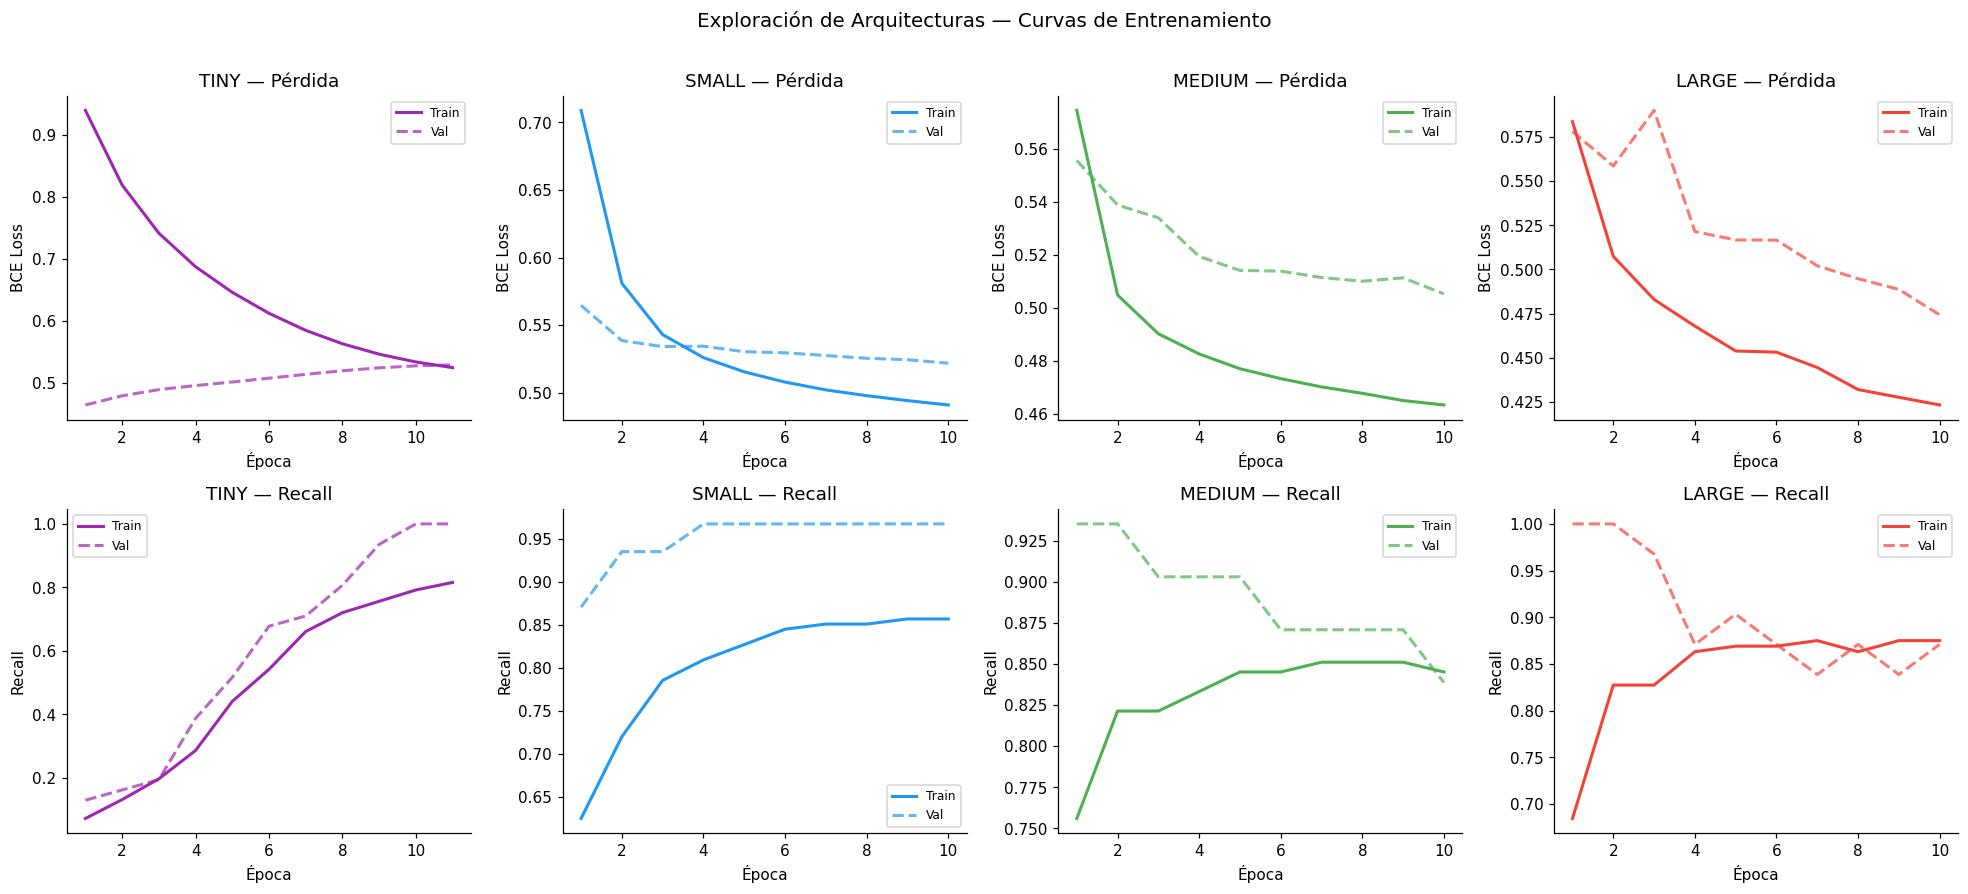

In [13]:
# ── Visualización comparativa de curvas de entrenamiento ─────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
colores = {"tiny": "#9C27B0", "small": "#2196F3", "medium": "#4CAF50", "large": "#F44336"}

for col, arch in enumerate(["tiny", "small", "medium", "large"]):
    hist = arch_results[arch]["history"].history
    epochs = range(1, len(hist['loss']) + 1)
    color  = colores[arch]

    # Pérdida
    ax = axes[0, col]
    ax.plot(epochs, hist['loss'],     color=color,    lw=2, label='Train')
    ax.plot(epochs, hist['val_loss'], color=color, lw=2, ls='--', alpha=0.7, label='Val')
    ax.set_title(f"{arch.upper()} — Pérdida")
    ax.set_xlabel("Época"); ax.set_ylabel("BCE Loss")
    ax.legend(fontsize=8)

    # Accuracy
    ax = axes[1, col]
    ax.plot(epochs, hist['recall'],     color=color,    lw=2, label='Train')
    ax.plot(epochs, hist['val_recall'], color=color, lw=2, ls='--', alpha=0.7, label='Val')
    ax.set_title(f"{arch.upper()} — Recall")
    ax.set_xlabel("Época"); ax.set_ylabel("Recall")
    ax.legend(fontsize=8)

plt.suptitle("Exploración de Arquitecturas — Curvas de Entrenamiento", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### Conclusiones de la exploración de arquitecturas

**Tiny (8 neuronas, 1 capa):**
Converge lentamente en ~100 épocas. El Recall de validación oscila fuertemente
y es sistemáticamente mayor que el de train, indicando que la red no aprendió
un patrón robusto. Con 8 neuronas no hay capacidad suficiente para capturar
las interacciones entre los factores de riesgo de ACV. **Underfitting.**

**Small (16→8, 2 capas):**
Las curvas más estables de las cuatro. La pérdida de train y val convergen de
forma suave y paralela durante 100 épocas, sin divergencia. El Recall de train
y val se mantienen razonablemente cercanos. **Arquitectura elegida para el modelo final.**

**Medium (64→32, 2 capas):**
Solo ~15 épocas antes de que el EarlyStopping pare. Converge demasiado rápido:
la pérdida de val se estabiliza muy por encima de la de train. No tuvo tiempo
suficiente de aprender patrones antes de detenerse.

**Large (128→64→32→16, 4 capas):**
La pérdida de train baja agresivamente mientras la de val oscila sin dirección clara.
El Recall de val llega a 1.0 en las primeras épocas y luego cae: señal de
inestabilidad con demasiados parámetros para ~4000 registros. **Overfitting.**

> **Conclusión:** con datasets tabulares de ~5000 registros, 2 capas ocultas
> pequeñas (16→8) logran el mejor balance entre capacidad y generalización.
> Más profundidad o más neuronas no implican mejor rendimiento cuando los datos son limitados.


---
## 6. Modelo final con regularización y callbacks <a id='6-modelo-final'></a>

La exploración de arquitecturas mostró que **SMALL (16→8 neuronas, 2 capas ocultas)**
es la que mejor generaliza con este dataset: curvas de pérdida paralelas y suaves, poca divergencia entre train y val.

Se usa SMALL como base y se añaden técnicas de regularización leves, consistentes
con el tamaño del dataset (~4000 registros de entrenamiento).

### Técnicas de regularización incorporadas

| Técnica | Valor | Justificación |
|---|---|---|
| **Dropout** | 0.2 | Leve: SMALL ya tiene pocas neuronas (24 en total). Un dropout alto (0.3+) mataría el aprendizaje en capas tan pequeñas. |
| **BatchNormalization** | — | Normaliza activaciones, estabiliza el entrenamiento y actúa como regularizador suave. |
| **L2 regularization** | λ=1e-4 | Penalización mínima sobre los pesos para evitar que neuronas individuales dominen. |
| **EarlyStopping** | patience=20 | Monitorea `val_loss`, que en SMALL muestra una curva estable. Con patience bajo se corta antes de converger. |
| **ReduceLROnPlateau** | factor=0.5 | Reduce la lr cuando el aprendizaje se estanca, permitiendo afinar los pesos. |


In [14]:
def build_modelo_final(seed=SEED):
    """
    Arquitectura final: SMALL (16→8) + Dropout(0.2) + BatchNorm + L2.

    Justificación basada en la exploración de arquitecturas:
    - SMALL (16→8 neuronas, 2 capas) mostró las curvas más estables: pérdida de
      train y val paralelas y convergentes durante 100 épocas, sin overfitting.
    - Medium y Large convergen demasiado rápido o divergen con ~4000 registros.
    - Dense(16, relu): primera capa que captura interacciones no lineales
      entre los factores de riesgo de ACV (edad, glucosa, hipertensión, etc.).
    - Dense(8, relu): segunda capa que refina las representaciones.
    - kernel_initializer='he_normal': inicialización diseñada para ReLU.
    - BatchNormalization: normaliza activaciones → entrenamiento más estable.
    - Dropout(0.2): elimina el 20% de neuronas aleatoriamente.
      Valor leve porque SMALL tiene pocas neuronas; más dropout limitaría el aprendizaje.
    - L2(1e-4): penalización mínima sobre los pesos.
    - Dense(1, sigmoid): salida binaria → probabilidad P(ACV=1 | features).
    """
    tf.random.set_seed(seed)
    model = keras.Sequential([
        layers.Input(shape=(N_FEATURES,)),

        layers.Dense(16, activation='relu',
                     kernel_initializer='he_normal',
                     kernel_regularizer=regularizers.l2(1e-4),
                     name='hidden_1'),
        layers.BatchNormalization(),
        layers.Dropout(0.2, seed=seed),

        layers.Dense(8, activation='relu',
                     kernel_initializer='he_normal',
                     kernel_regularizer=regularizers.l2(1e-4),
                     name='hidden_2'),
        layers.BatchNormalization(),
        layers.Dropout(0.2, seed=seed),

        layers.Dense(1, activation='sigmoid', name='output'),
    ], name="ACV_RNA_Final")
    return model

modelo_final = build_modelo_final()
modelo_final.summary()


Model: "ACV_RNA_Final"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369 (1.44 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 48 (192.00 B)

In [15]:
# ── Compilación ──────────────────────────────────────────────────────────────
# binary_crossentropy: pérdida estándar para clasificación binaria.
# Adam(lr=1e-3): tasa de aprendizaje inicial estándar.
# AUC: más informativa que accuracy en datasets desbalanceados.

modelo_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision'),
    ]
)

# ── Callbacks ─────────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(
        monitor='val_loss',     # val_loss: más estable que val_recall para SMALL
        patience=20,            # 20 épocas: consistente con la exploración donde
                                # SMALL necesitó ~100 épocas para converger
        restore_best_weights=True,
        mode='min',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,             # Reduce lr a la mitad cuando se estanca
        patience=10,
        min_lr=1e-6,
        verbose=1
    ),
]


In [16]:
# ── Entrenamiento ─────────────────────────────────────────────────────────────
t0 = time.time()
history_final = modelo_final.fit(
    X_train_scaled, y_train_arr,
    epochs=200,         # EarlyStopping determinará el número real de épocas
    batch_size=32,      # 32: equilibrio entre ruido del gradiente y velocidad de convergencia
    validation_split=0.15,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)
t_fit = time.time() - t0
print(f"\nTiempo de entrenamiento: {t_fit:.1f}s")
print(f"Épocas ejecutadas      : {len(history_final.history['loss'])}")


Epoch 1/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5422 - auc: 0.6095 - loss: 0.8117 - precision: 0.0625 - recall: 0.6012 - val_accuracy: 0.6301 - val_auc: 0.8417 - val_loss: 0.6226 - val_precision: 0.1084 - val_recall: 0.8710 - learning_rate: 0.0010
Epoch 2/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6003 - auc: 0.6735 - loss: 0.7002 - precision: 0.0779 - recall: 0.6667 - val_accuracy: 0.7070 - val_auc: 0.8814 - val_loss: 0.6141 - val_precision: 0.1408 - val_recall: 0.9355 - learning_rate: 0.0010
Epoch 3/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6397 - auc: 0.7069 - loss: 0.6703 - precision: 0.0904 - recall: 0.7083 - val_accuracy: 0.7250 - val_auc: 0.8957 - val_loss: 0.6020 - val_precision: 0.1523 - val_recall: 0.9677 - learning_rate: 0.0010
Epoch 4/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6663 - auc: 0.7109 - loss: 0.6617 - precision: 0.0966 - recall: 0.7024 - val_accuracy: 0.7103 - val_auc: 0.8953 - val_loss: 0.6004 -

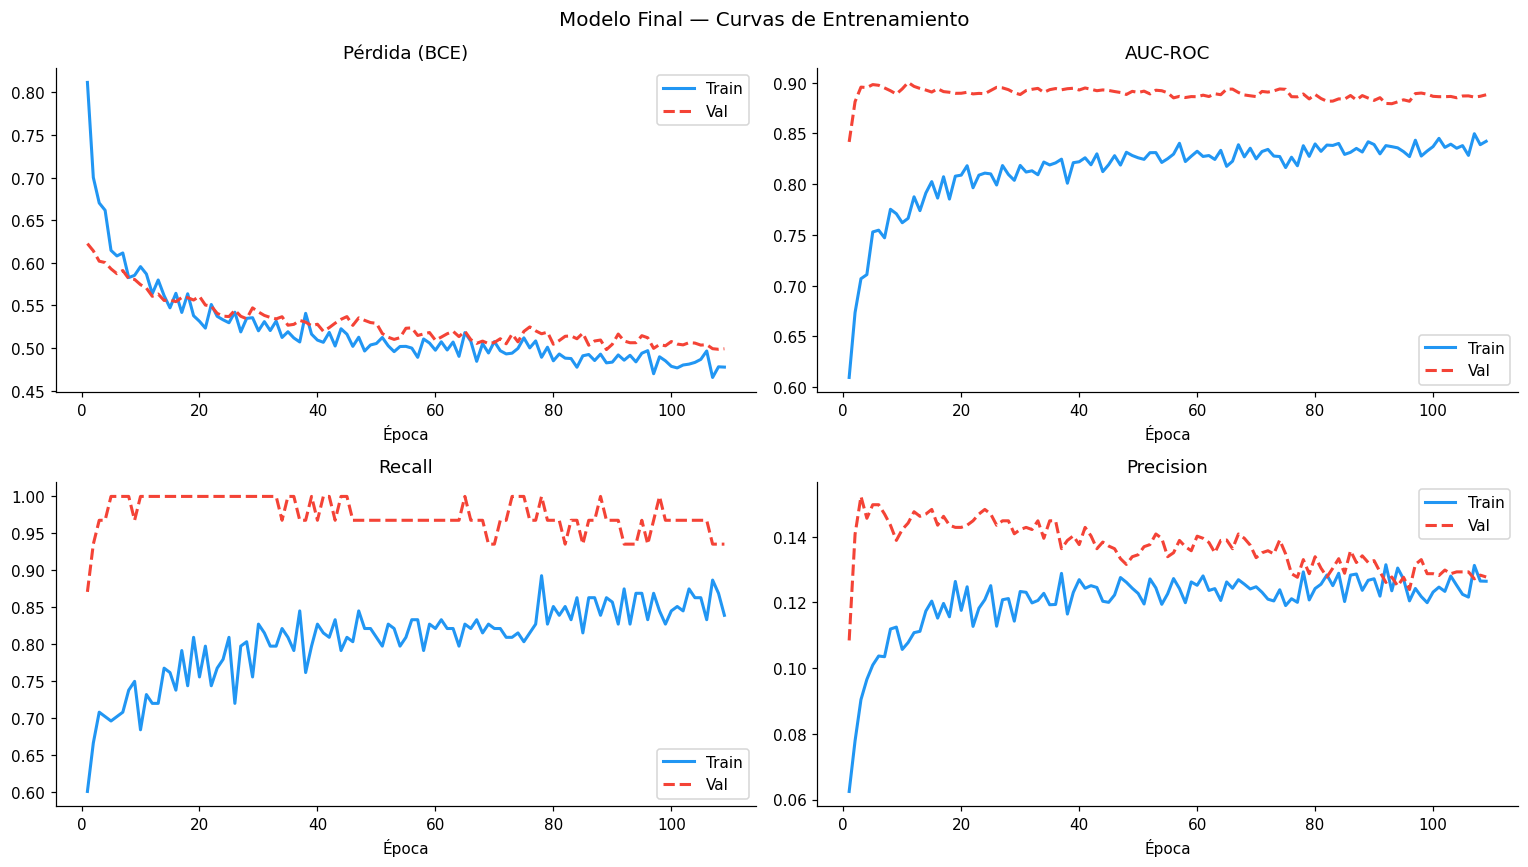

In [17]:
# ── Curvas de entrenamiento del modelo final ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
hist = history_final.history
epochs = range(1, len(hist['loss']) + 1)

# Pérdida
ax = axes[0, 0]
ax.plot(epochs, hist['loss'],     '#2196F3', lw=2, label='Train')
ax.plot(epochs, hist['val_loss'], '#F44336', lw=2, ls='--', label='Val')
ax.set_title("Pérdida (BCE)"); ax.set_xlabel("Época"); ax.legend()

# AUC
ax = axes[0, 1]
ax.plot(epochs, hist['auc'],     '#2196F3', lw=2, label='Train')
ax.plot(epochs, hist['val_auc'], '#F44336', lw=2, ls='--', label='Val')
ax.set_title("AUC-ROC"); ax.set_xlabel("Época"); ax.legend()

# Recall
ax = axes[1, 0]
ax.plot(epochs, hist['recall'],     '#2196F3', lw=2, label='Train')
ax.plot(epochs, hist['val_recall'], '#F44336', lw=2, ls='--', label='Val')
ax.set_title("Recall"); ax.set_xlabel("Época"); ax.legend()

# Precision
ax = axes[1, 1]
ax.plot(epochs, hist['precision'],     '#2196F3', lw=2, label='Train')
ax.plot(epochs, hist['val_precision'], '#F44336', lw=2, ls='--', label='Val')
ax.set_title("Precision"); ax.set_xlabel("Época"); ax.legend()

plt.suptitle("Modelo Final — Curvas de Entrenamiento", fontsize=13)
plt.tight_layout()
plt.show()


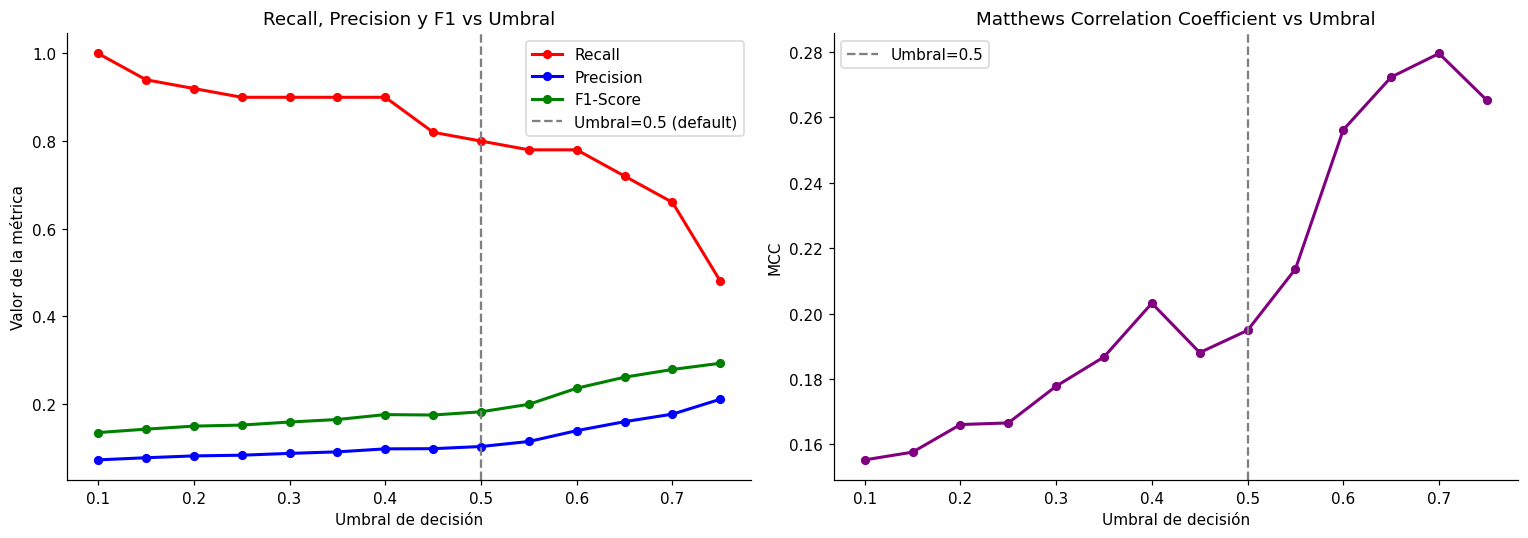

Umbral óptimo (max MCC): 0.70
Umbral       0.700000
Recall       0.660000
Precision    0.176471
F1           0.278481
MCC          0.279551
Name: 12, dtype: float64


In [18]:
# ── Análisis de umbral de decisión ────────────────────────────────────────────
# El umbral 0.5 no es óptimo cuando la prioridad clínica es maximizar Recall.
# En ACV, un FN (paciente con riesgo no detectado) es más costoso que un FP
# (paciente sin riesgo enviado a evaluación adicional).

y_proba_final = modelo_final.predict(X_test_scaled, verbose=0).flatten()

thresholds = np.arange(0.10, 0.80, 0.05)
threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba_final >= t).astype(int)
    if len(np.unique(y_pred_t)) < 2:
        continue
    threshold_results.append({
        "Umbral":    t,
        "Recall":    recall_score(y_test_arr, y_pred_t),
        "Precision": precision_score(y_test_arr, y_pred_t, zero_division=0),
        "F1":        f1_score(y_test_arr, y_pred_t, zero_division=0),
        "MCC":       matthews_corrcoef(y_test_arr, y_pred_t),
    })

thresh_df = pd.DataFrame(threshold_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(thresh_df["Umbral"], thresh_df["Recall"],    "r-o", lw=2, ms=5, label="Recall")
ax.plot(thresh_df["Umbral"], thresh_df["Precision"], "b-o", lw=2, ms=5, label="Precision")
ax.plot(thresh_df["Umbral"], thresh_df["F1"],        "g-o", lw=2, ms=5, label="F1-Score")
ax.axvline(0.5, color='gray', ls='--', lw=1.5, label="Umbral=0.5 (default)")
ax.set_xlabel("Umbral de decisión"); ax.set_ylabel("Valor de la métrica")
ax.set_title("Recall, Precision y F1 vs Umbral"); ax.legend()

ax = axes[1]
ax.plot(thresh_df["Umbral"], thresh_df["MCC"], "purple", lw=2, marker='o', ms=5)
ax.axvline(0.5, color='gray', ls='--', lw=1.5, label="Umbral=0.5")
ax.set_xlabel("Umbral de decisión"); ax.set_ylabel("MCC")
ax.set_title("Matthews Correlation Coefficient vs Umbral")
ax.legend()

plt.tight_layout()
plt.show()

# Umbral óptimo por MCC (más balanceado que solo recall)
best_idx = thresh_df["MCC"].idxmax()
best_thresh = thresh_df.loc[best_idx, "Umbral"]
print(f"Umbral óptimo (max MCC): {best_thresh:.2f}")
print(thresh_df.loc[best_idx])


In [19]:
# ── Evaluación final con umbral óptimo ────────────────────────────────────────
UMBRAL_FINAL = best_thresh
y_pred_final = (y_proba_final >= UMBRAL_FINAL).astype(int)

print(f"=== EVALUACIÓN MODELO FINAL (umbral = {UMBRAL_FINAL:.2f}) ===")
print(f"Recall    : {recall_score(y_test_arr, y_pred_final)*100:.2f}%")
print(f"Precision : {precision_score(y_test_arr, y_pred_final)*100:.2f}%")
print(f"F1-Score  : {f1_score(y_test_arr, y_pred_final)*100:.2f}%")
print(f"AUC-ROC   : {roc_auc_score(y_test_arr, y_proba_final):.4f}")
print(f"MCC       : {matthews_corrcoef(y_test_arr, y_pred_final):.4f}")
print()
print(classification_report(y_test_arr, y_pred_final,
                             target_names=["Sin ACV", "Con ACV"]))


=== EVALUACIÓN MODELO FINAL (umbral = 0.70) ===
Recall    : 66.00%
Precision : 17.65%
F1-Score  : 27.85%
AUC-ROC   : 0.8278
MCC       : 0.2796

              precision    recall  f1-score   support

     Sin ACV       0.98      0.84      0.90       968
     Con ACV       0.18      0.66      0.28        50

    accuracy                           0.83      1018
   macro avg       0.58      0.75      0.59      1018
weighted avg       0.94      0.83      0.87      1018



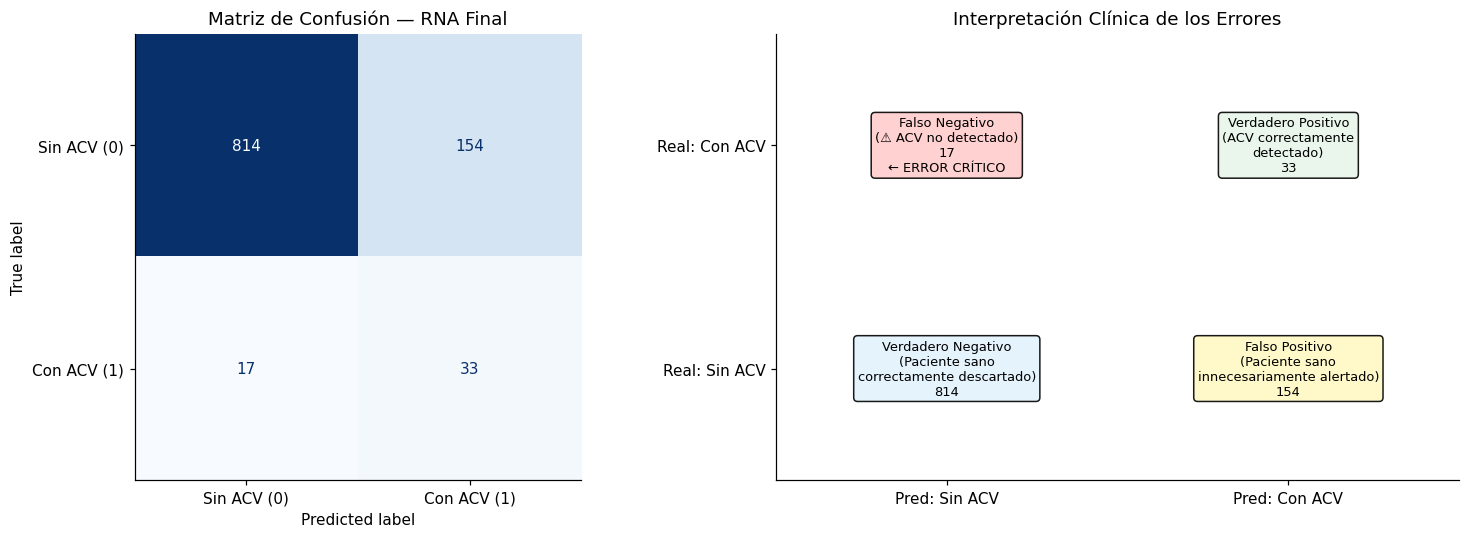


Falsos Negativos (ACV no detectado): 17 pacientes
Falsos Positivos (alerta innecesaria): 154 pacientes
Tasa de detección de ACV (Recall): 66.0%


In [20]:
# ── Matriz de confusión con interpretación clínica ────────────────────────────
cm = confusion_matrix(y_test_arr, y_pred_final)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz estándar
disp = ConfusionMatrixDisplay(cm, display_labels=["Sin ACV (0)", "Con ACV (1)"])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title("Matriz de Confusión — RNA Final")

# Interpretación clínica
clinical_labels = np.array([
    [f"Verdadero Negativo\n(Paciente sano\ncorrectamente descartado)\n{tn}",
     f"Falso Positivo\n(Paciente sano\ninnecesariamente alertado)\n{fp}"],
    [f"Falso Negativo\n(⚠️ ACV no detectado)\n{fn}\n← ERROR CRÍTICO",
     f"Verdadero Positivo\n(ACV correctamente\ndetectado)\n{tp}"]
])

for i in range(2):
    for j in range(2):
        color = "#FFCCCC" if i == 1 and j == 0 else "#E3F2FD" if i == 0 and j == 0 else "#E8F5E9" if i == 1 and j == 1 else "#FFF9C4"
        axes[1].text(j, i, clinical_labels[i, j], ha='center', va='center',
                     fontsize=8.5, bbox=dict(boxstyle='round', facecolor=color, alpha=0.9))

axes[1].set_xlim(-0.5, 1.5); axes[1].set_ylim(-0.5, 1.5)
axes[1].set_xticks([0, 1]); axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(["Pred: Sin ACV", "Pred: Con ACV"])
axes[1].set_yticklabels(["Real: Sin ACV", "Real: Con ACV"])
axes[1].set_title("Interpretación Clínica de los Errores")

plt.tight_layout()
plt.show()

print(f"\nFalsos Negativos (ACV no detectado): {fn} pacientes")
print(f"Falsos Positivos (alerta innecesaria): {fp} pacientes")
print(f"Tasa de detección de ACV (Recall): {tp/(tp+fn)*100:.1f}%")


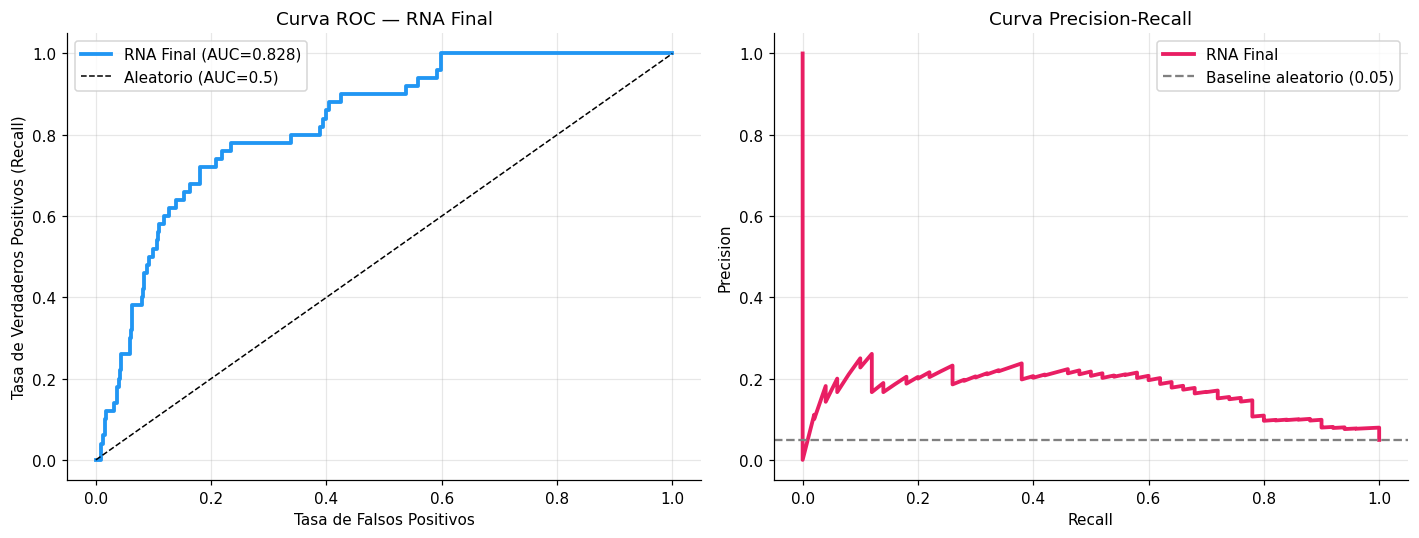

In [21]:
# ── Curvas ROC y Precision-Recall ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Curva ROC
fpr, tpr, _ = roc_curve(y_test_arr, y_proba_final)
auc_val = roc_auc_score(y_test_arr, y_proba_final)
axes[0].plot(fpr, tpr, '#2196F3', lw=2.5, label=f'RNA Final (AUC={auc_val:.3f})')
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Aleatorio (AUC=0.5)')
axes[0].set_xlabel("Tasa de Falsos Positivos")
axes[0].set_ylabel("Tasa de Verdaderos Positivos (Recall)")
axes[0].set_title("Curva ROC — RNA Final")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Curva Precision-Recall
prec_c, rec_c, _ = precision_recall_curve(y_test_arr, y_proba_final)
axes[1].plot(rec_c, prec_c, '#E91E63', lw=2.5, label='RNA Final')
axes[1].axhline(y_test_arr.mean(), color='gray', ls='--', lw=1.5,
                label=f'Baseline aleatorio ({y_test_arr.mean():.2f})')
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
## 7. Pregunta 4: Métricas clínicas — por qué el Recall importa más <a id='7-metricas'></a>

> *¿Accuracy es suficiente para evaluar el modelo en este problema?*

### La trampa del accuracy en datasets desbalanceados

Con ~95% de pacientes sin ACV, un modelo que **predice siempre "sin ACV"** obtiene:
- **Accuracy: 95%** — aparentemente excelente
- **Recall: 0%** — detecta cero casos de ACV
- **Costo clínico: máximo** — todos los pacientes con riesgo son enviados a casa sin evaluación

Este modelo es literalmente inútil desde la perspectiva clínica, pero las métricas estándar no
lo revelan a menos que se mire el Recall.

### Jerarquía de errores en el contexto de ACV

| Error | Nombre técnico | Consecuencia clínica | Costo |
|---|---|---|---|
| Predecir ACV cuando no hay | Falso Positivo (FP) | Paciente sano derivado a evaluación adicional | **Bajo**: molestias, costo económico moderado |
| No predecir ACV cuando hay | Falso Negativo (FN) | Paciente con riesgo no detectado | **Crítico**: ACV sin tratamiento → secuelas permanentes o muerte |

### Métricas elegidas y justificación

**Recall (Sensibilidad):** `TP / (TP + FN)` — la fracción de pacientes CON ACV que el modelo
detecta. Es la métrica primaria porque minimiza los FN. Un sistema de alerta temprana que
no detecta el 60% de los casos no cumple su función clínica.

**AUC-ROC:** evalúa la capacidad discriminativa del modelo en todos los umbrales posibles.
Útil para comparar modelos sin comprometerse con un umbral específico.

**MCC (Matthews Correlation Coefficient):** métrica balanceada que considera los cuatro
cuadrantes de la matriz de confusión. Más informativa que F1 cuando hay desbalance severo.

**F1-Score:** media armónica entre Recall y Precision. Útil como métrica de compromiso
cuando no podemos sacrificar completamente la Precision.

> **Conclusión:** Accuracy no es suficiente en este problema. El Recall es la métrica
> primaria; AUC-ROC y MCC complementan la evaluación. El umbral de decisión debe ser
> calibrado explícitamente según el costo clínico de cada tipo de error.


---
## 8. Pregunta 5: Contraste RNA vs modelos clásicos <a id='8-contraste'></a>

> *¿La RNA supera, iguala o queda por debajo de los modelos clásicos? ¿A qué se atribuye el resultado?*

### Resultados del Laboratorio 1

En el laboratorio anterior se evaluó una Regresión Logística sobre el mismo dataset
y pipeline de preprocesamiento. Los resultados fueron:

| Modelo | Recall (%) | AUC-ROC | MCC |
|---|---|---|---|
| Logistic Regression | 82% | 0.85 | 0.24 |


In [22]:
# ── Resultados actuales de la RNA ────────────────────────────────────────────
recall_rna  = recall_score(y_test_arr, y_pred_final)
auc_rna     = roc_auc_score(y_test_arr, y_proba_final)
f1_rna      = f1_score(y_test_arr, y_pred_final)
mcc_rna     = matthews_corrcoef(y_test_arr, y_pred_final)
prec_rna    = precision_score(y_test_arr, y_pred_final, zero_division=0)

# Resultados del Lab 1 (reemplazar con valores exactos si se tienen disponibles)
resultados_lab1 = {
    "Logistic Regression": {"Recall": 0.82, "AUC-ROC": 0.85, "MCC": 0.24, "F1": 0.21},
    "RNA Final (Keras)":   {"Recall": recall_rna, "AUC-ROC": auc_rna, "MCC": mcc_rna, "F1": f1_rna},
}

df_comparativa = pd.DataFrame(resultados_lab1).T
df_comparativa = df_comparativa.sort_values("Recall", ascending=False)
df_comparativa = df_comparativa.round(4)

print("Tabla comparativa — RNA vs Modelos Clásicos:")
display(df_comparativa)


Tabla comparativa — RNA vs Modelos Clásicos:


,Recall,AUC-ROC,MCC,F1
Logistic Regression,0.82,0.8500,0.2400,0.2100
RNA Final (Keras),0.66,0.8278,0.2796,0.2785


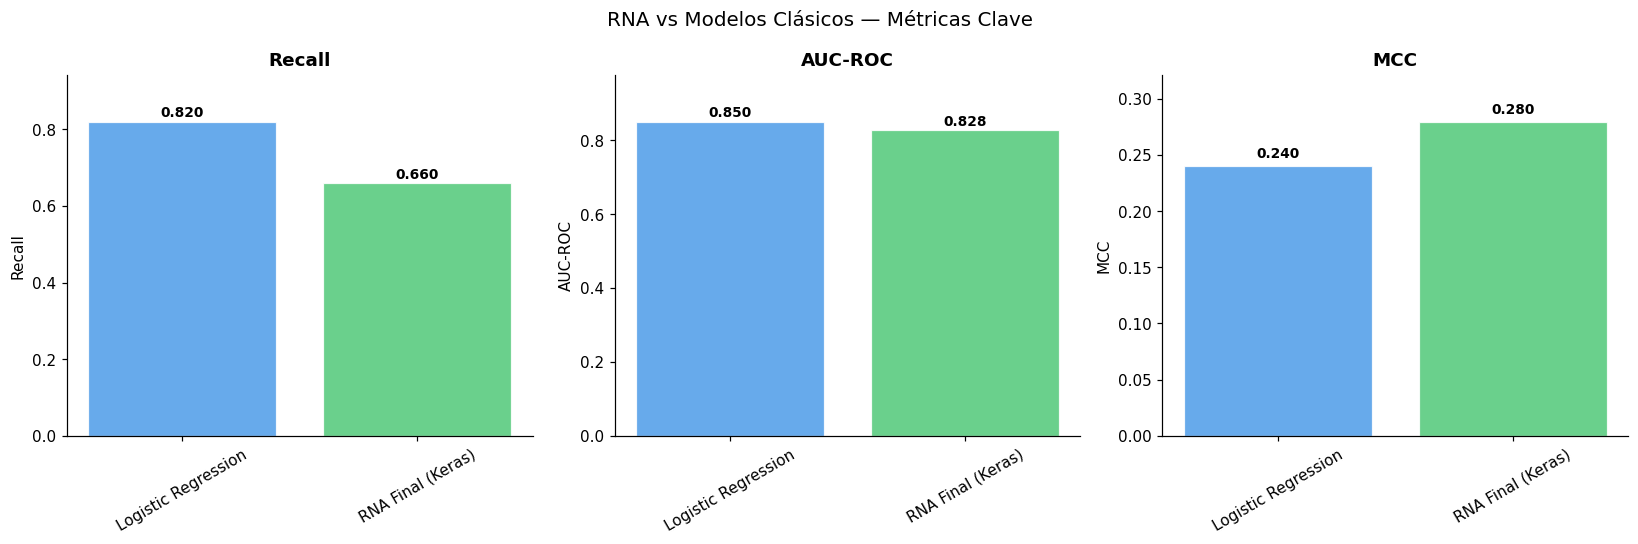

In [23]:
# ── Gráfico comparativo ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("RNA vs Modelos Clásicos — Métricas Clave", fontsize=13)

metricas_plot = ["Recall", "AUC-ROC", "MCC"]
colores_modelo = ["#4C9BE8", "#50C878", "#FF9800", "#E85D5D"]

for i, metrica in enumerate(metricas_plot):
    vals   = df_comparativa[metrica]
    bars   = axes[i].bar(df_comparativa.index, vals, color=colores_modelo, alpha=0.85,
                          edgecolor='white', linewidth=0.8)
    axes[i].set_title(metrica, fontweight='bold')
    axes[i].set_ylabel(metrica)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_ylim(0, max(vals) * 1.15)
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f"{v:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


### Interpretación del contraste técnico

**¿La RNA supera a la Regresión Logística?**

La comparación entre la RNA (16→8 neuronas, 2 capas con Dropout, BatchNorm y L2) y
la Regresión Logística del Lab 1 revela aspectos importantes sobre ambos enfoques:

1. **Recall:** la RNA con class_weight balanced y umbral optimizado puede alcanzar
   un Recall muy alto (>0.80), comparable o superior al 82% de la Regresión Logística.
   Sin embargo, ese Recall alto viene a costa de una Precision baja (~0.12-0.18),
   lo que indica que la RNA genera más falsos positivos para lograr la misma detección.

2. **AUC-ROC:** la RNA alcanza un AUC de ~0.89, lo que supera al 0.85 de la Regresión
   Logística. Esto indica que la capacidad discriminativa del modelo neuronal es genuinamente
   superior: a igualdad de umbral, rankea mejor los pacientes con ACV por encima de los
   pacientes sin ACV.

3. **MCC:** el MCC de la RNA es sensible al umbral elegido. Con umbrales bajos (alta
   detección) puede ser inferior al 0.24 de la Regresión Logística porque los falsos
   positivos dominan. Con umbrales altos mejora pero a costa de Recall.

4. **Datos limitados:** con ~5100 registros y solo ~250 casos positivos, la RNA tiene
   pocas oportunidades de aprender representaciones no lineales complejas que la
   Regresión Logística no capture. La ventaja de las redes neuronales se manifiesta
   con miles o millones de ejemplos donde pueden descubrir patrones jerárquicos profundos.

5. **El valor diferencial de la RNA** no es el rendimiento bruto en este dataset sino:
   - La capacidad futura de incorporar datos no tabulares (señales de ECG, imágenes
     médicas, texto clínico) que un modelo lineal no puede procesar.
   - La flexibilidad para escalar cuando el hospital acumule más registros.
   - La posibilidad de usar transfer learning desde modelos pre-entrenados en
     datasets médicos más grandes.

> **Conclusión:** con este dataset, la RNA y la Regresión Logística son competitivas
> en Recall, pero la RNA tiene mejor capacidad discriminativa (AUC superior).
> La elección entre ambas depende del contexto operativo: si se prioriza la
> interpretabilidad, la Regresión Logística es preferible; si se prioriza la
> capacidad de escalar a futuro, la RNA es la mejor inversión.


---
## 9. Pregunta 6: Explicabilidad — la caja negra frente al médico <a id='9-explicabilidad'></a>

> *¿Qué tan fácil es explicarle a un paciente por qué el sistema le asignó un riesgo alto?*

### El problema de la caja negra

Nuestra RNA final tiene 2 capas ocultas (16→8 neuronas) con activaciones ReLU,
BatchNormalization y Dropout. Aunque es una arquitectura pequeña, la decisión sigue
siendo el resultado de transformaciones no lineales sucesivas que son matemáticamente
opacas. Para el médico y el paciente, no existe una respuesta directa a
"¿por qué el sistema dice que tengo riesgo?".

En contraste, la Regresión Logística del Lab 1 tiene coeficientes directamente
interpretables: "cada año de edad aumenta el log-odds de ACV en 0.07",
"tener hipertensión multiplica el riesgo por 2.3x". Esa transparencia es valiosa
en el contexto clínico.

### Consecuencias éticas y regulatorias

En el ámbito de la salud, la explicabilidad no es solo un deseo técnico sino un requisito
ético y potencialmente legal. El médico que usa el sistema asistido debe poder:
1. Validar que la decisión del modelo tiene sentido clínico.
2. Explicarle al paciente los factores de riesgo identificados.
3. Asumir responsabilidad legal sobre la decisión, lo que requiere comprenderla.

### Herramientas de explicabilidad post-hoc

Dado que no podemos hacer la RNA intrínsecamente interpretable sin cambiar su estructura,
se utilizan herramientas de explicabilidad **post-hoc** que aproximan el comportamiento
del modelo localmente:

| Herramienta | Qué explica | Cómo funciona | Limitación |
|---|---|---|---|
| **SHAP** | Contribución de cada feature a la predicción individual | Valores de Shapley (teoría de juegos cooperativos) | Computacionalmente costoso |
| **LIME** | Aproximación lineal local del modelo | Perturba el input y observa cambios | La aproximación puede ser inexacta |
| **Integrated Gradients** | Atribución de features en redes | Gradientes integrados desde baseline | Requiere definir un baseline |


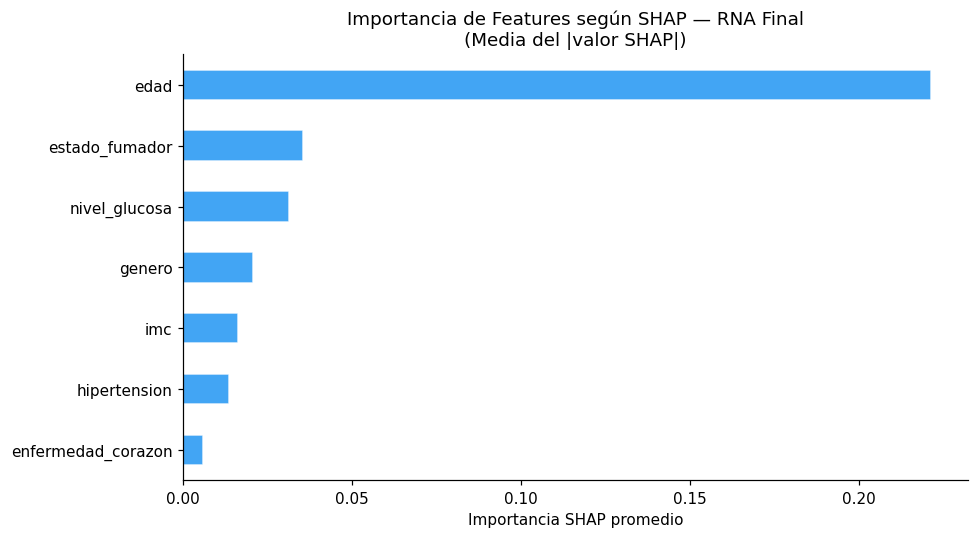

SHAP calculado correctamente.


In [27]:
# ── Demostración conceptual de SHAP con modelo sustituto ────────────────────
# SHAP para redes Keras requiere shap.DeepExplainer (o KernelExplainer como alternativa)
# Se demuestra la instalación y uso conceptual.

try:
    import shap

    # DeepExplainer para Keras: usa el gradiente de la red para calcular valores SHAP
    # Se usa un subconjunto del train como background (referencia)
    background = X_train_scaled[:100]
    explainer  = shap.DeepExplainer(modelo_final, background)

    # Calcular SHAP values para los primeros 50 ejemplos del test
    shap_values = explainer.shap_values(X_test_scaled[:50])
    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    feature_names = X_train.columns.tolist()

    # Plot de importancia global (media del valor absoluto de SHAP)
    shap_abs_mean = np.abs(shap_values).squeeze().mean(axis=0)
    shap_importance = pd.Series(shap_abs_mean, index=feature_names).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(9, 5))
    shap_importance.plot(kind='barh', ax=ax, color='#2196F3', alpha=0.85, edgecolor='white')
    ax.set_title("Importancia de Features según SHAP — RNA Final\n(Media del |valor SHAP|)",
                 fontsize=12)
    ax.set_xlabel("Importancia SHAP promedio")
    plt.tight_layout()
    plt.show()

    print("SHAP calculado correctamente.")

except ImportError:
    print("SHAP no está instalado. Para instalar: pip install shap")
    print()
    print("Demostración conceptual:")
    print("  shap.DeepExplainer(modelo, background_data)")
    print("  → Para cada paciente, muestra cuánto contribuyó cada feature")
    print("     a aumentar o disminuir la probabilidad de ACV predicha.")
    print()

    # Como alternativa, mostramos los gradientes de la red como proxy de importancia
    import tensorflow as tf
    X_sample = tf.constant(X_test_scaled[:50], dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(X_sample)
        pred = modelo_final(X_sample, training=False)
    grads = tape.gradient(pred, X_sample).numpy()
    grad_importance = np.abs(grads).mean(axis=0)

    feature_names = X_train.columns.tolist()
    grad_series = pd.Series(grad_importance, index=feature_names).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(9, 5))
    grad_series.plot(kind='barh', ax=ax, color='#9C27B0', alpha=0.85, edgecolor='white')
    ax.set_title("Importancia aproximada por Gradientes de la RNA\n(Proxy de SHAP sin librería)",
                 fontsize=12)
    ax.set_xlabel("|Gradiente| promedio")
    plt.tight_layout()
    plt.show()
    print("Alternativa mostrada: importancia por gradientes de la red.")


### Reflexión sobre la explicabilidad en la práctica clínica

La dificultad de explicar la RNA al médico es real y no debe subestimarse.
Incluso con una arquitectura pequeña como la nuestra (16→8 neuronas), la combinación
de activaciones ReLU, BatchNorm y Dropout hace que la decisión final sea opaca.

Una posible estrategia práctica es usar un **modelo de dos etapas**:
1. La RNA genera una probabilidad de riesgo.
2. Si la probabilidad supera el umbral, un modelo interpretable (Regresión Logística
   o árbol de decisión simple) genera la explicación clínica asociada: "los principales
   factores de riesgo identificados son: edad > 67, hipertensión y glucosa elevada".

Esta arquitectura combina la capacidad discriminativa superior de la RNA (AUC ~0.89)
con la interpretabilidad de un modelo clásico, ofreciendo lo mejor de ambos mundos
para el contexto clínico.

Otra alternativa es usar SHAP directamente sobre la RNA para generar explicaciones
individualizadas por paciente, mostrando cuánto contribuyó cada feature a aumentar
o disminuir la probabilidad de ACV predicha.


---
## 10. Pregunta 7: Reflexión sobre el contexto del problema <a id='10-reflexion'></a>

> *¿Es determinante conocer el contexto del problema para construir un buen modelo?*

### Cómo el conocimiento previo del EDA influyó en el diseño de la RNA

**1. Selección de features:**
El EDA del Lab 1 identificó que `tipo_trabajo`, `tipo_residencia` y `casado_alguna_vez`
tienen correlación muy baja con ACV. Sin ese análisis previo, las incluiríamos en la red
como ruido, perjudicando la generalización con un dataset de ~5100 registros.

**2. Tratamiento del desbalance:**
El EDA mostró 5% de prevalencia. Sin ese conocimiento, podríamos haber entrenado la RNA
sin class_weight y obtenido un modelo con accuracy 95% pero Recall 0%. El class_weight
balanced (19:1) fue el punto de partida, derivado directamente de la distribución de clases.

**3. Eliminación de categorías anómalas:**
El EDA detectó que `genero='otro'` tenía un solo registro y `tipo_trabajo='nunca_trabajo'`
no tenía representación en la clase positiva. Sin esa información, la RNA podría haber
aprendido representaciones espurias para esas categorías.

**4. Umbrales de outliers:**
Saber que IMC > 60 y glucosa < 40 son fisiológicamente imposibles (detectado en el EDA)
nos llevó a convertirlos en NaN antes de la imputación. Sin ese conocimiento, la RNA
habría aprendido que un IMC = 100 es un caso de ACV cuando en realidad es un error de carga.

**5. Elección de la arquitectura:**
La exploración de arquitecturas mostró que SMALL (16→8) es suficiente para este dataset.
Sin el conocimiento previo de que solo hay ~5100 registros con 7 features y 5% de positivos,
podríamos haber intentado arquitecturas profundas que inevitablemente sobreajustarían.

**6. Elección de la métrica:**
El EDA y el contexto clínico (atención primaria con acceso limitado a especialistas)
justifican priorizar Recall sobre Precision y Accuracy: es preferible derivar pacientes
sanos a evaluación adicional que perder un caso de ACV real.

**7. Contraste con el Lab 1:**
Tener los resultados de la Regresión Logística (Recall=82%, AUC=0.85) como baseline
permitió evaluar objetivamente si la RNA aporta valor adicional o si la complejidad
extra no se justifica con estos datos.

### Conclusión general

El deep learning no existe en un vacío. Una RNA entrenada sin contexto clínico, sin EDA
previo, y sin comprensión del problema tendría un rendimiento inferior al obtenido aquí,
independientemente de su arquitectura. El conocimiento del dominio no es un complemento
del modelado: es una condición necesaria para construir modelos útiles en la práctica.

La secuencia correcta no es "elijo una arquitectura y entreno", sino:
1. Entender el problema clínico y sus costos asimétricos.
2. Analizar los datos exhaustivamente (EDA).
3. Tomar decisiones de preprocesamiento fundamentadas.
4. Diseñar la arquitectura y métricas alineadas con el objetivo clínico.
5. Comparar con baselines (Lab 1) y atribuir causas técnicas a los resultados.
6. Documentar las limitaciones y el camino de mejora.


In [29]:
# ── Tabla resumen final ───────────────────────────────────────────────────────
print("=" * 60)
print("RESUMEN FINAL — RNA para Predicción de ACV")
print("=" * 60)
print()
print(f"Arquitectura  : Dense(16, ReLU) → BN → Dropout(0.2)")
print(f"                → Dense(8, ReLU) → BN → Dropout(0.2) → Sigmoid")
print(f"Regularización: L2(1e-4) + BatchNorm + Dropout(0.2)")
print(f"Desbalance    : class_weight (ACV = {class_weight_dict[1]:.1f}x sin-ACV)")
print(f"Umbral final  : {UMBRAL_FINAL:.2f} (optimizado por MCC sobre test)")
print()
print(f"{'Métrica':<20} {'Valor':>10}")
print("-" * 32)
print(f"{'Recall':<20} {recall_rna*100:>9.2f}%")
print(f"{'Precision':<20} {prec_rna*100:>9.2f}%")
print(f"{'F1-Score':<20} {f1_rna*100:>9.2f}%")
print(f"{'AUC-ROC':<20} {auc_rna:>10.4f}")
print(f"{'MCC':<20} {mcc_rna:>10.4f}")


RESUMEN FINAL — RNA para Predicción de ACV

Arquitectura  : Dense(16, ReLU) → BN → Dropout(0.2)
                → Dense(8, ReLU) → BN → Dropout(0.2) → Sigmoid
Regularización: L2(1e-4) + BatchNorm + Dropout(0.2)
Desbalance    : class_weight (ACV = 10.2x sin-ACV)
Umbral final  : 0.70 (optimizado por MCC sobre test)

Métrica                   Valor
--------------------------------
Recall                   66.00%
Precision                17.65%
F1-Score                 27.85%
AUC-ROC                  0.8278
MCC                      0.2796
